In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


In [2]:
transform=transforms.Compose([
    transforms.Resize((224,224)),    
    transforms.ToTensor() 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.3 * size)
test_size=int(0.6*size)
train_size = int(size - test_size-valid_size)
trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [8]:
sum=[0]*10
for d,t,_ in trainset:
    for i in range(10):
        if(t==i):
            sum[i]+=1
sum

[488, 499, 509, 467, 534, 492, 522, 516, 488, 485]

In [9]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_29.pth')

In [10]:
summary(model_0,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.8622243204593658, 0.7128)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.0046163363138834, 0.6613333333333333)

In [13]:
each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
each_accu

airplane      0.680328
automobile    0.773547
bird          0.557957
cat           0.451820
deer          0.812734
dog           0.626016
frog          0.833333
horse         0.695736
ship          0.815574
truck         0.859794
dtype: float64

In [14]:
targetF=[x  for x in each_accu.nsmallest(3).index.map(trainset.dataset.classess)]
targetF

[3, 2, 5]

In [15]:
# 將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()

    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
         

            # print(loss)
            for idx,t,pred in zip(idx,target,y_pred_tag):
                
                if(split_mode=='T'):
                    if(t!=pred):
                        flat_true.append(len(data_dl.dataset.dataset.classes))
                    else:
                        flat_true.append(t.cpu().item())  
                else:
                    if(t!=pred):
                        flat_true.append(t.cpu().item())
                    else:
                        flat_true.append(len(data_dl.dataset.dataset.classes)) 
                
                            
            flat_data.extend(data.cpu().numpy()) 

    return flat_data,flat_true

In [16]:
#建立dataset class
class TandFDataset(Dataset):
    def __init__(self, x,y):
        super().__init__()
        self.x = x        
        self.y = y
        self.classes={label: i for i, label in enumerate (set(self.y))}
    
    def __len__(self):
        return len(self.y)
   
    def __getitem__(self,idx):

        image=self.x[idx]
  
        label=torch.tensor(self.y[idx])

        return image,label,idx
    def get_labels(self):
        return self.y
    

In [17]:
#將資料切分後建立dataset與dataloader
from torchsampler import ImbalancedDatasetSampler
data_T,label_T=split_data(model_0,train_dl,split_mode="T")
data_F,label_F=split_data(model_0,train_dl,split_mode="F")

Fdataset=TandFDataset(data_T,label_T)
Tdataset=TandFDataset(data_F,label_F)
Fdl=DataLoader(Fdataset, batch_size=batch_size,sampler=ImbalancedDatasetSampler(Fdataset))
Tdl=DataLoader(Tdataset, batch_size=batch_size,sampler=ImbalancedDatasetSampler(Tdataset))


In [18]:
#將資料切分後建立dataset與dataloader

data_T_v,label_T_v=split_data(model_0,valid_dl,split_mode="T")
data_F_v,label_F_v=split_data(model_0,valid_dl,split_mode="F")

Fdataset_v=TandFDataset(data_T_v,label_T_v)
Tdataset_v=TandFDataset(data_F_v,label_F_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [19]:
sum=[0]*11
for d,t,_ in Tdataset:
    for i in range(11):
        if(t==i):
            sum[i]+=1
sum

[156, 113, 225, 256, 100, 184, 87, 157, 90, 68, 3564]

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=2.1207136360168457,train_accu=0.25
Epoch=0,valid_loss=2.2503796301523846,valid_accu=0.1148
0
Epoch=1,train_loss=2.0226057975769045,train_accu=0.2812
Epoch=1,valid_loss=2.2680314355214435,valid_accu=0.11546666666666666
0
Epoch=2,train_loss=1.9462160507202149,train_accu=0.311
Epoch=2,valid_loss=2.2682287275950115,valid_accu=0.11873333333333333
0
Epoch=3,train_loss=1.9177875230789185,train_accu=0.3106
Epoch=3,valid_loss=2.35353693300883,valid_accu=0.0954
Epoch=4,train_loss=1.8837024534225464,train_accu=0.3462
Epoch=4,valid_loss=2.357386315790812,valid_accu=0.1114
Epoch=5,train_loss=1.829625560760498,train_accu=0.3758
Epoch=5,valid_loss=2.383810913213094,valid_accu=0.102
3 Early stopping!


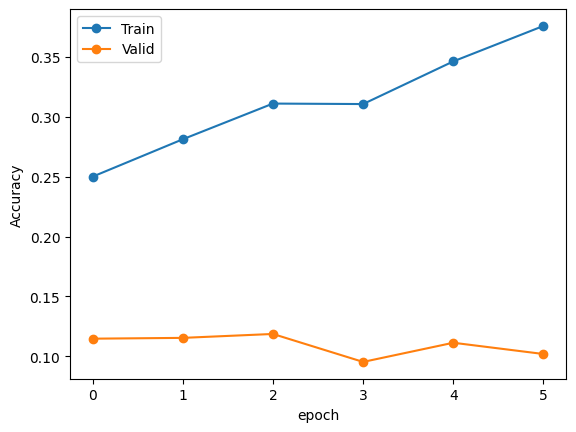

In [20]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [21]:
set(Tdataset.y)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}

In [22]:
Fdl.dataset.classes

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10}

In [24]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=1.4766467267990113,train_accu=0.5962
Epoch=0,valid_loss=1.6683399203618368,valid_accu=0.46186666666666665
0
Epoch=1,train_loss=1.2319317638397216,train_accu=0.6358
Epoch=1,valid_loss=1.5741397460301718,valid_accu=0.48506666666666665
0
Epoch=2,train_loss=1.0864739318847656,train_accu=0.6902
Epoch=2,valid_loss=1.3883807634353638,valid_accu=0.5371333333333334
0
Epoch=3,train_loss=1.0093995601654053,train_accu=0.698
Epoch=3,valid_loss=1.2695790355682373,valid_accu=0.5643333333333334
0
Epoch=4,train_loss=0.9545886964797974,train_accu=0.7308
Epoch=4,valid_loss=1.3603182245254517,valid_accu=0.5525333333333333
Epoch=5,train_loss=0.8803664404869079,train_accu=0.7488
Epoch=5,valid_loss=1.2855356740315755,valid_accu=0.5661333333333334
0
Epoch=6,train_loss=0.8672312317848205,train_accu=0.7412
Epoch=6,valid_loss=1.2409024073282877,valid_accu=0.5679333333333333
0
Epoch=7,train_loss=0.8115359485626221,train_accu=0.7688
Epoch=7,valid_loss=1.2764711065292358,valid_accu=0.569066666666

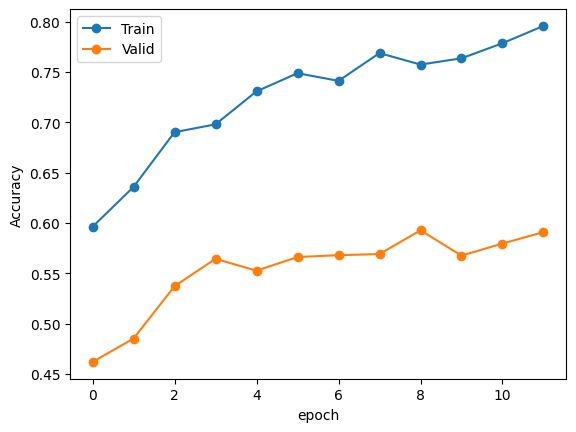

In [25]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [26]:
#模型表現
def evaluate_model(model,data_dl,size,data_name,mode=None):
        model.to(device)
        ######################    
        # validate the model #
        ######################
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
            model.eval()   

            for data, target,idx in data_dl:

                    data,target=data.to(device),target.to(device)
                    out= model(data)
                    _, y_pred_tag = torch.max(out, dim = 1)
                    
                    loss = criterion(out, target)
                    # print(target)
                    flat_true.extend(target.cpu().numpy())
                    flat_pred.extend(y_pred_tag.cpu().numpy())

                    total_loss+= loss.item()*data.size(0)
                    correct=torch.sum(y_pred_tag == target).item()
                    accu += correct      

            total_loss=total_loss/size
            accu=accu/size

        a=sorted(set(flat_true))

        
   
        if(mode=='eval'):
            if(data_name=='decision'):
                confusion_matrix_valid=pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a))
            elif(data_name=='T' or data_name=='F'):
                confusion_matrix_valid=pd.DataFrame(confusion_matrix(flat_true, flat_pred))
            else:
                idxtoclass={v:k for k,v in data_dl.dataset.dataset.classes}
                confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a)).rename(columns=idxtoclass,index=idxtoclass)
            return total_loss,accu,confusion_matrix_valid
        else:
            return total_loss,accu


In [27]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(1.9582699308395386, 0.2958)

In [28]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.7848444901466369, 0.782)

In [29]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(2.2682287366231284, 0.11873333333333333)

In [30]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.1612216824849446, 0.5926666666666667)

In [31]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(1.8504408641815187, 0.3268, 0)

In [32]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(1.8790131958643594, 0.3062666666666667, 0)

In [33]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0

    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_T = model_T(data)
            _, y_pred_T = torch.max(out_T, dim = 1)

            out_F = model_F(data)
            _, y_pred_F = torch.max(out_F, dim = 1)

            num_classes = len(data_dl.dataset.dataset.classes)
            special_class = num_classes + 1

            for pred_T,pred_F,d,t in zip(y_pred_T,y_pred_F,data,target):
                sum_T=0
                sum_F=0

                sum_T = 1 if pred_T == special_class else 0
                sum_F = 1 if pred_F == special_class else 0
                    
                
                if sum_T + sum_F != 1:
                    outputs.append(model_0(d.unsqueeze(0)))
                else:
                    if(sum_T ==1):
                        outputs.append(model_F(d.unsqueeze(0)))
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                    
            # print(len(outputs))
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)
        

            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())
            
            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F

In [35]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
total_train_loss,total_train_accu,sum

(0.8622245866775513, 0.7128, 0)

In [34]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss,total_valid_accu,sum

(1.0046158376057943, 0.6613333333333333, 0)

In [37]:
train_losses=[train_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [39]:
model_algos=['Model_0',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.862224,0.7128,1.004616,0.661333
1,Model_T,1.958270,0.2958,2.268229,0.118733
2,Model_F,0.784844,0.7820,1.161222,0.592667
3,Total_Model,0.862225,0.7128,1.004616,0.661333
4,Total_Model_without_decision,1.850441,0.3268,1.879013,0.306267


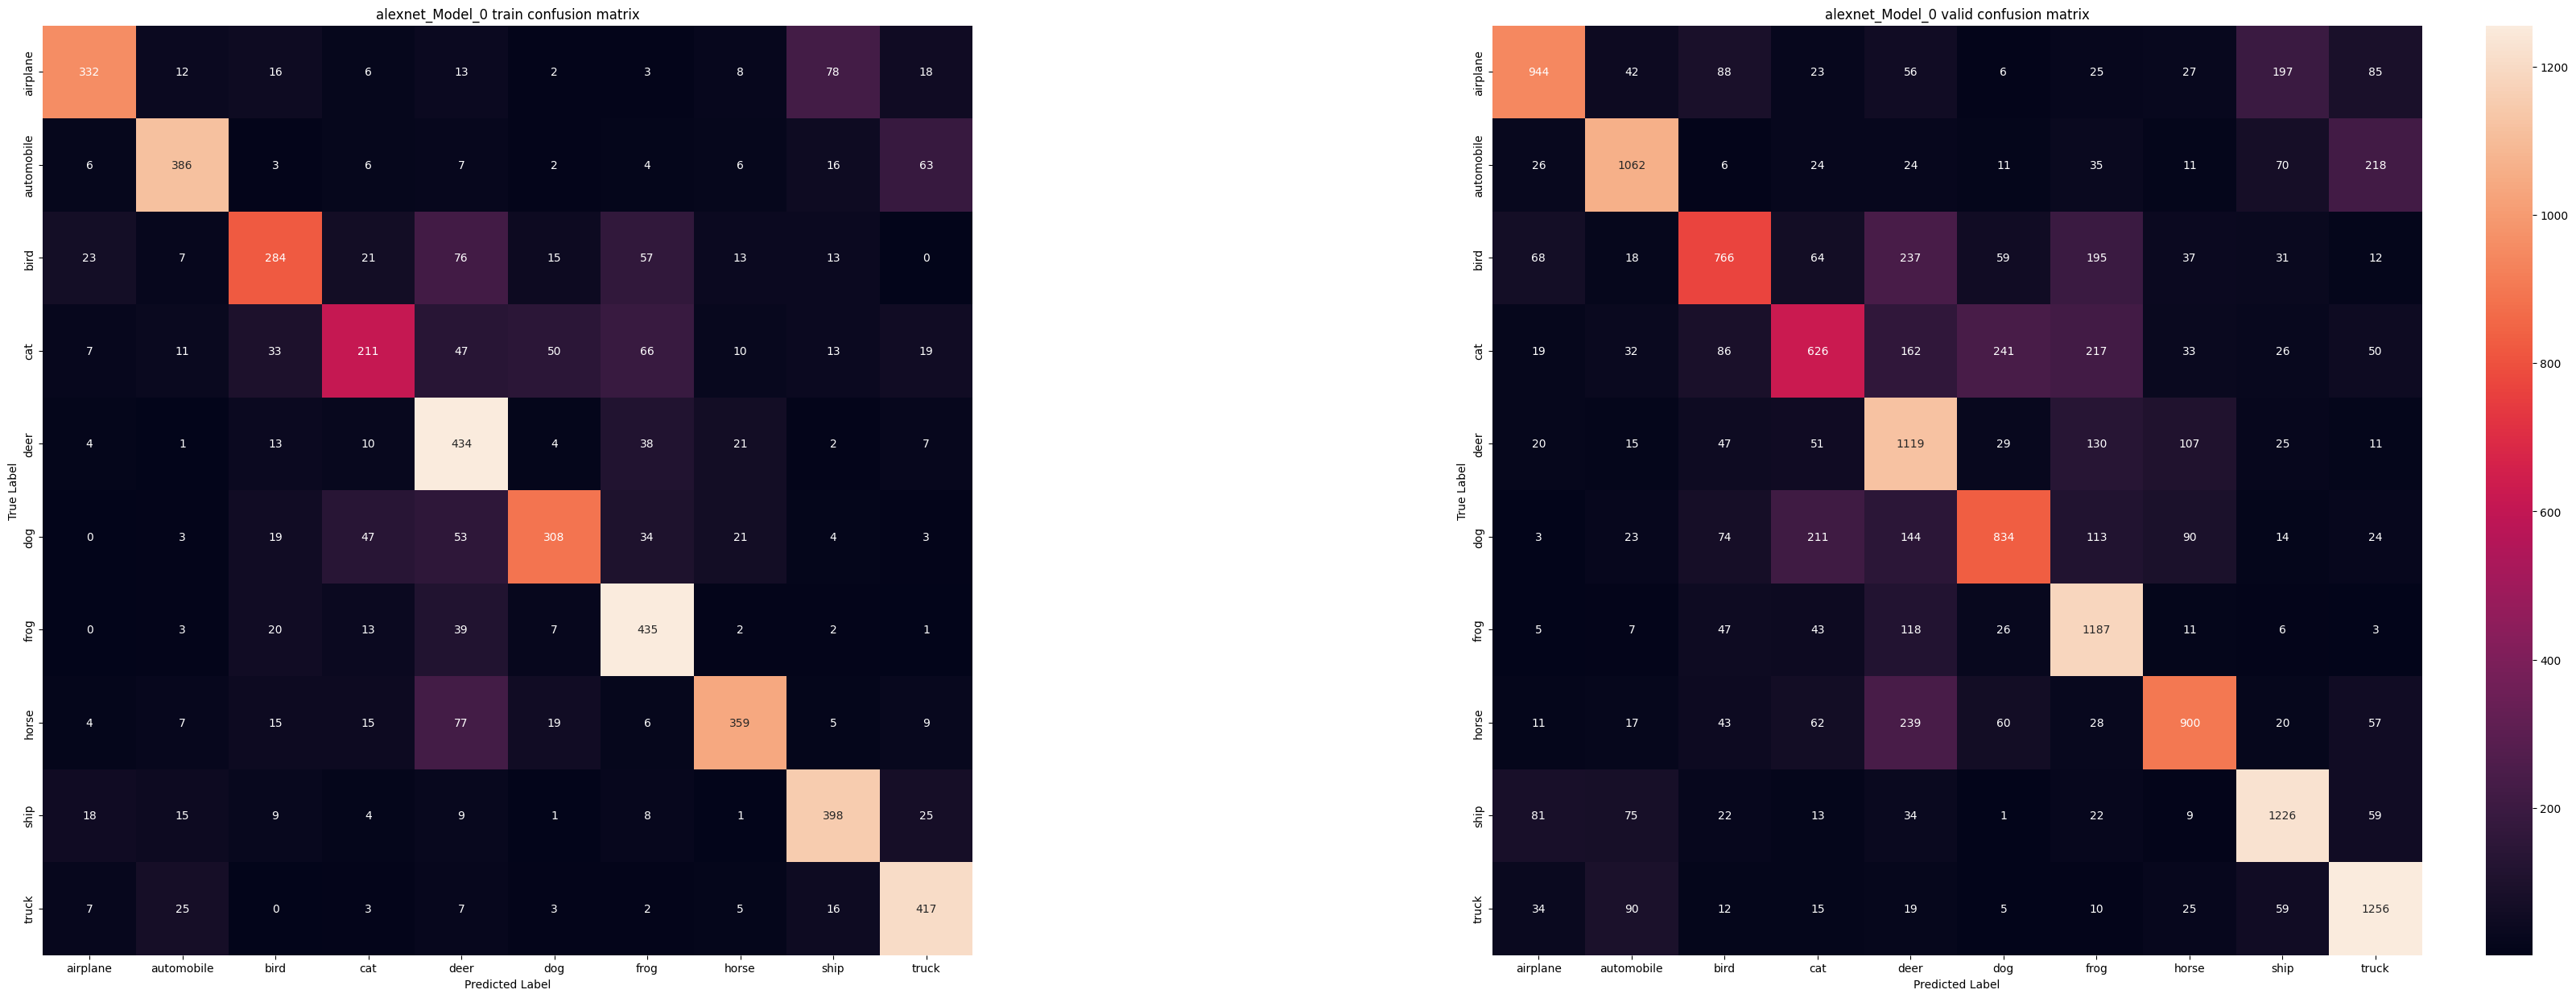

In [40]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

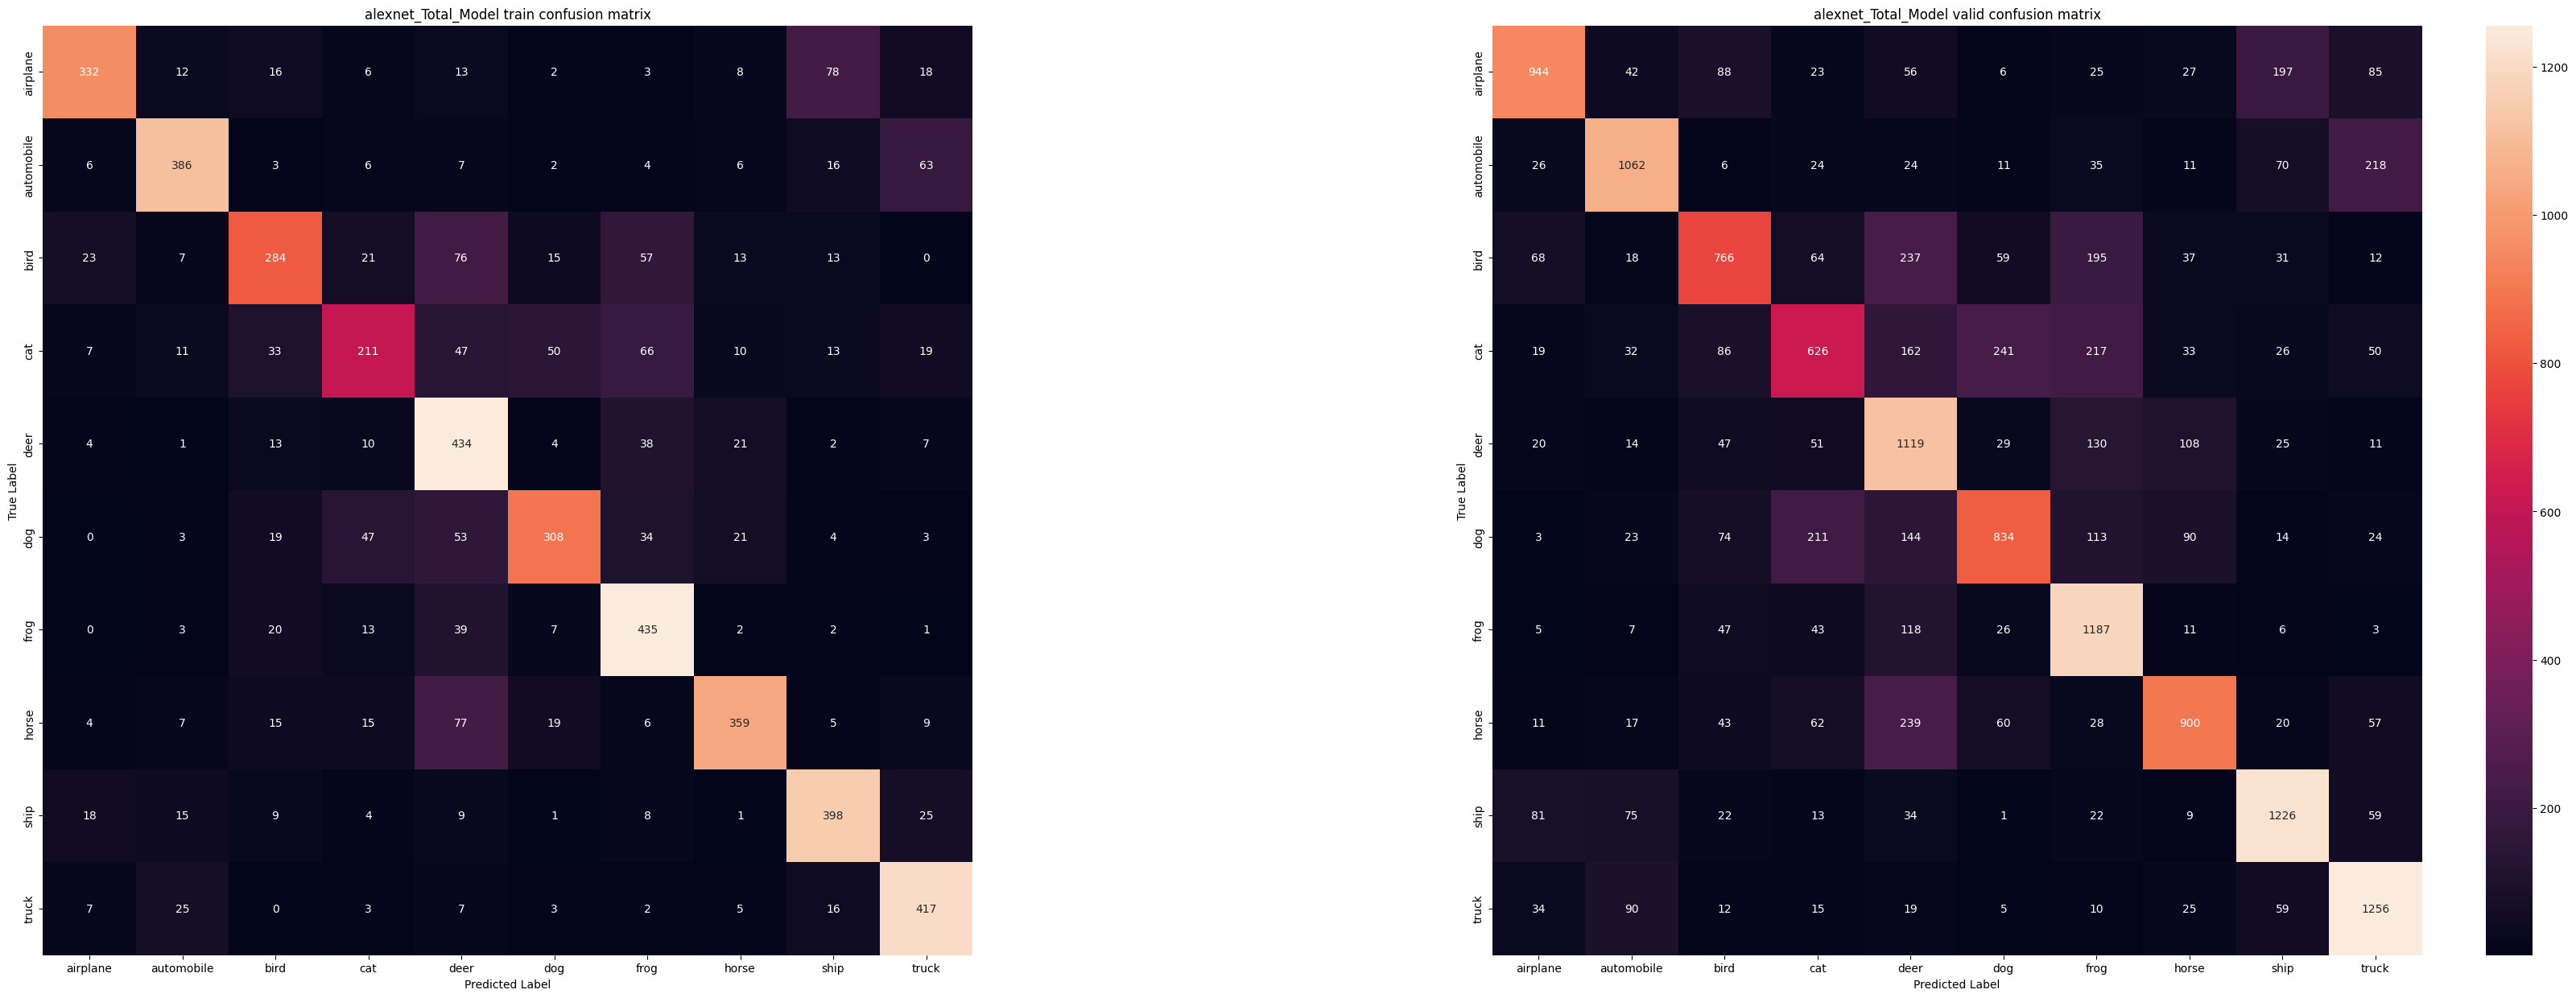

In [41]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

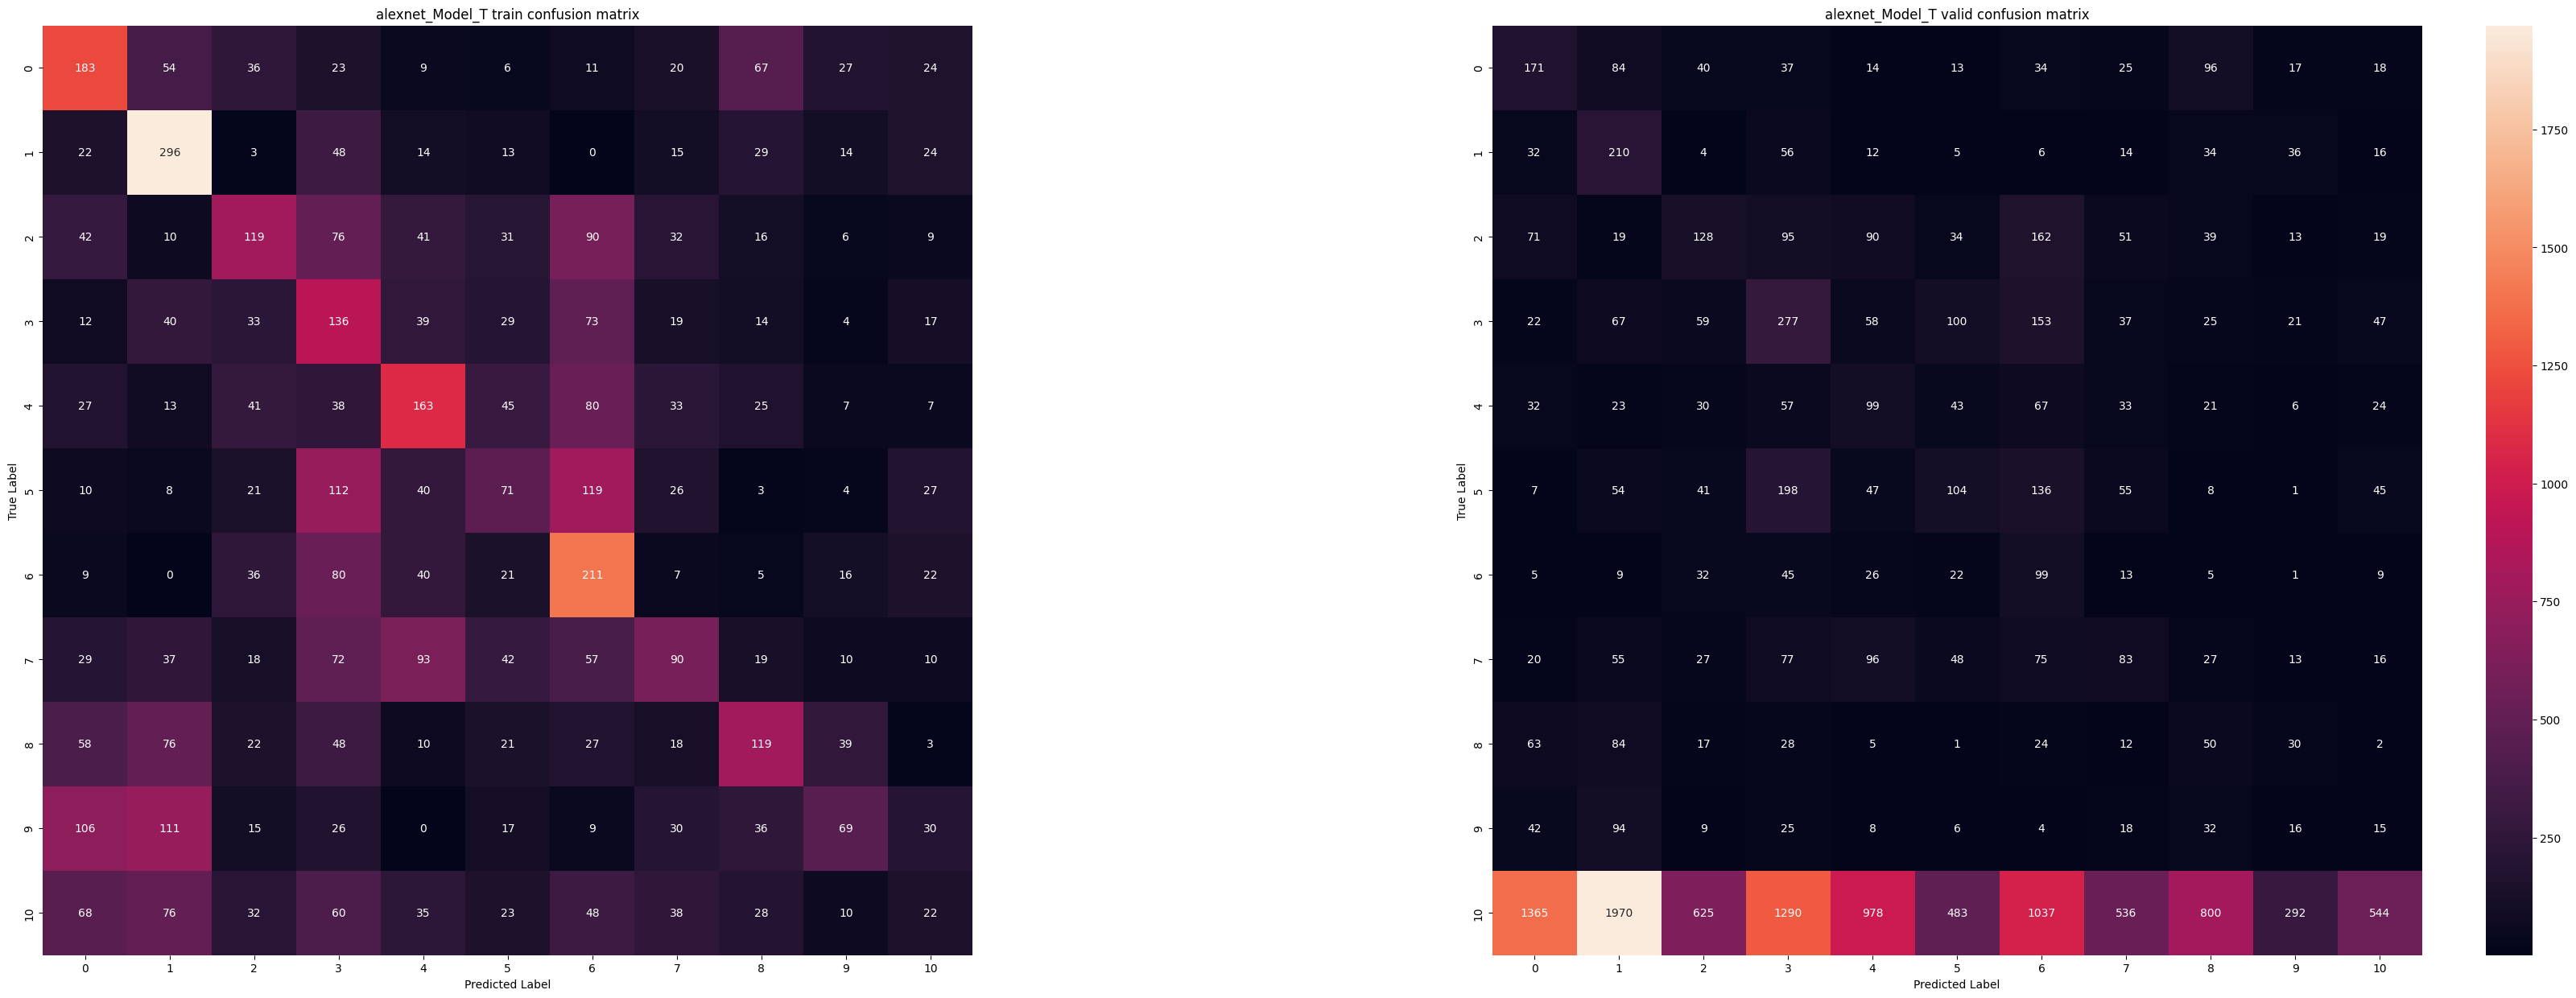

In [42]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

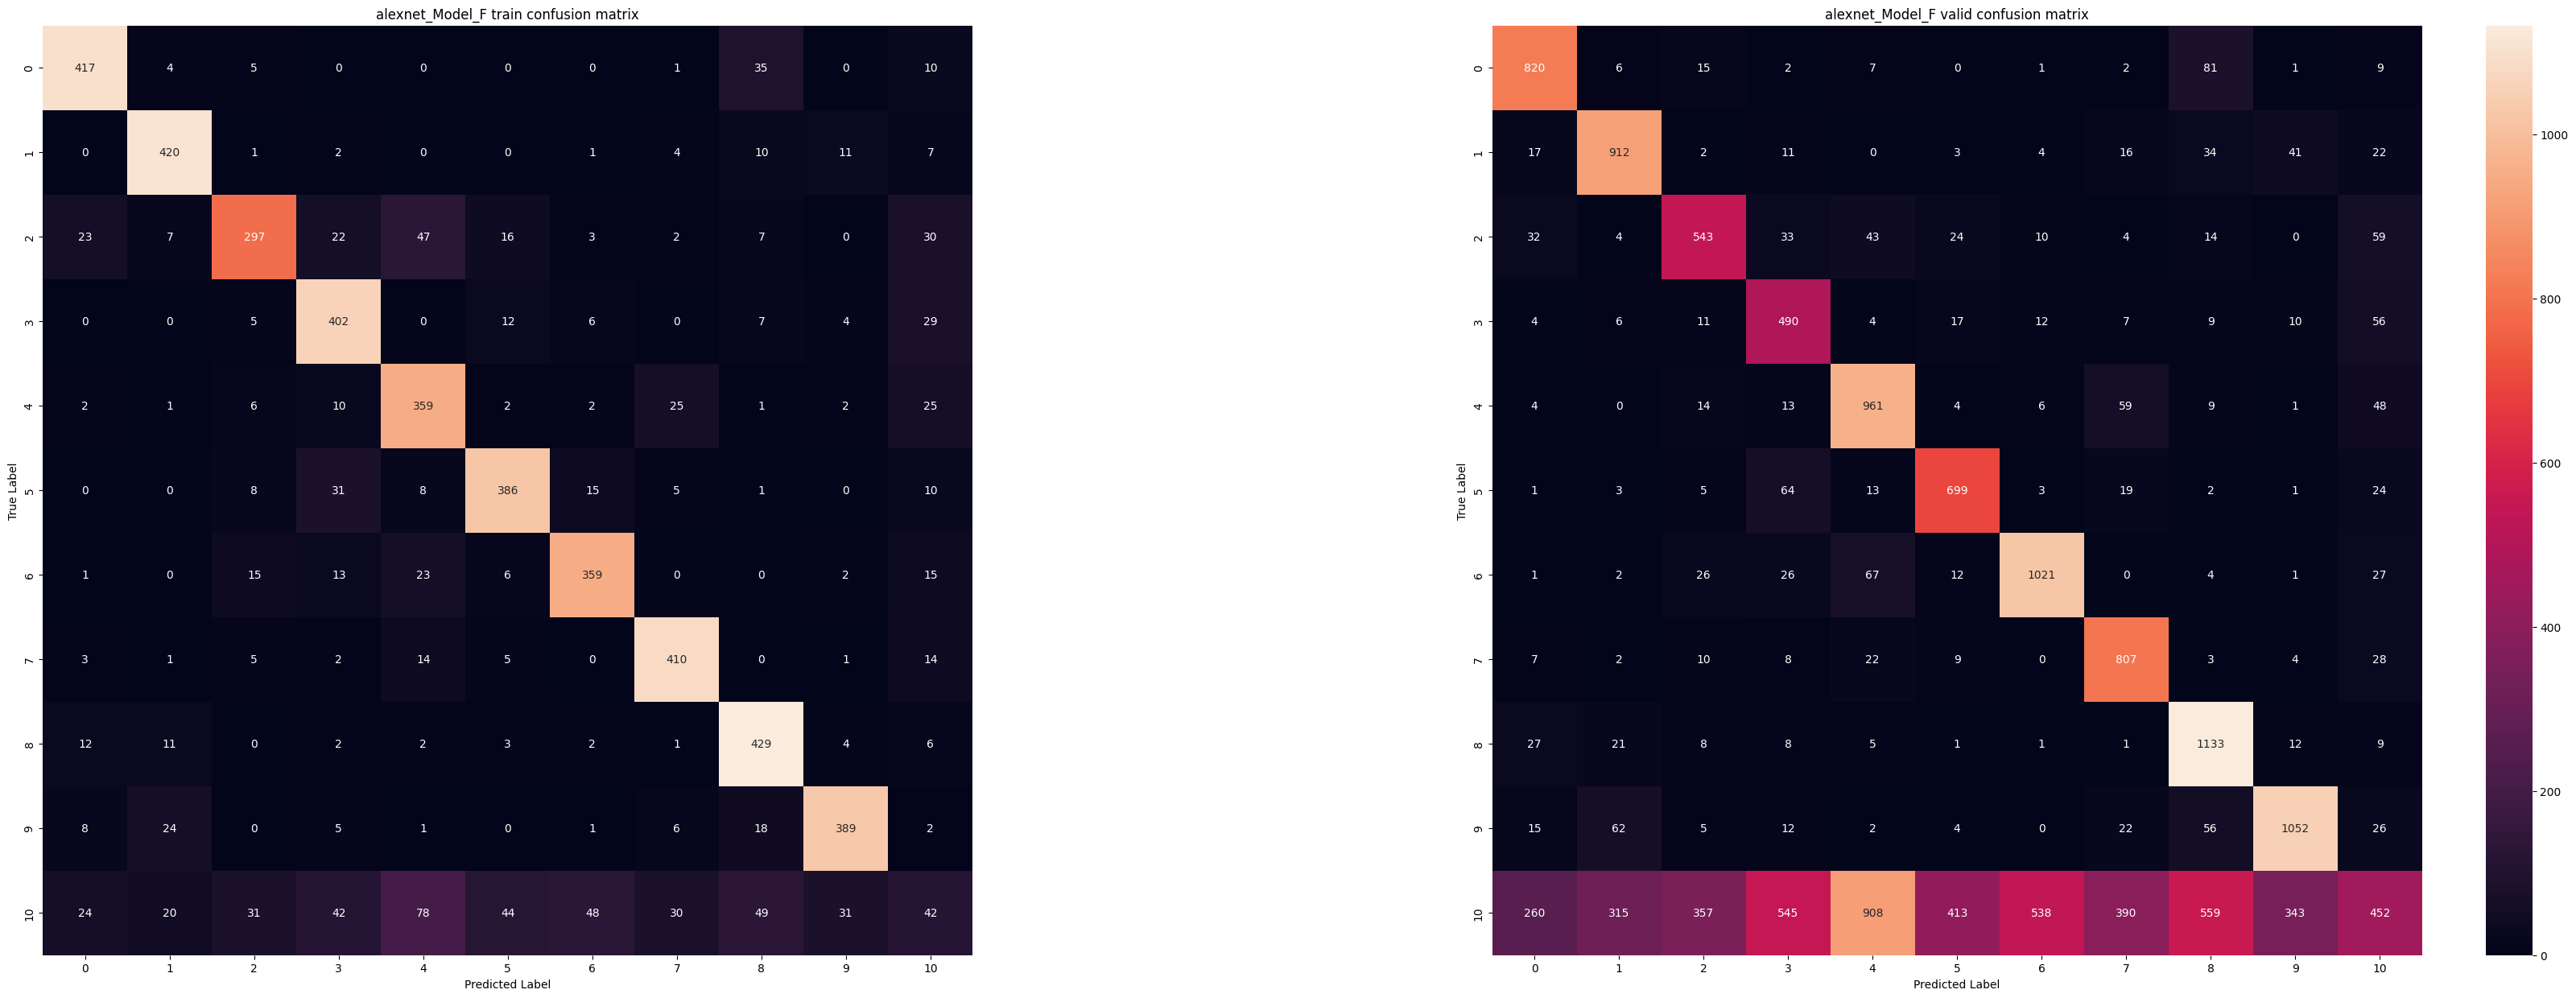

In [43]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)